
===== BÀI 1: PIPELINE =====
Shape sau pipeline: (10, 42)

===== BÀI 2: TEST PIPELINE =====
full: OK - shape (1500, 4348)
missing: OK - shape (1500, 4336)
skew: OK - shape (1500, 4348)
unseen: OK - shape (1500, 4345)
wrong_format: ERROR - Cannot use median strategy with non-numeric data:
could not convert string to float: 'abc'

So sánh phân phối...


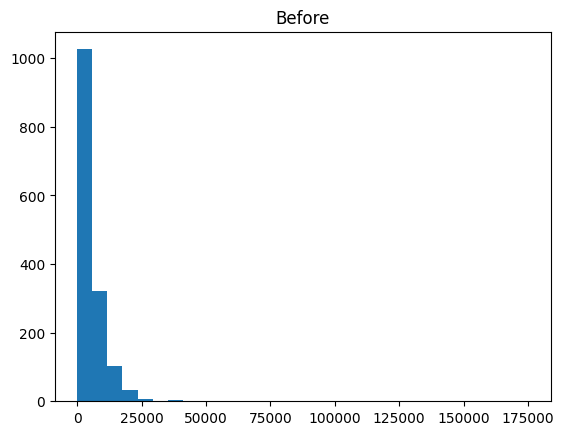

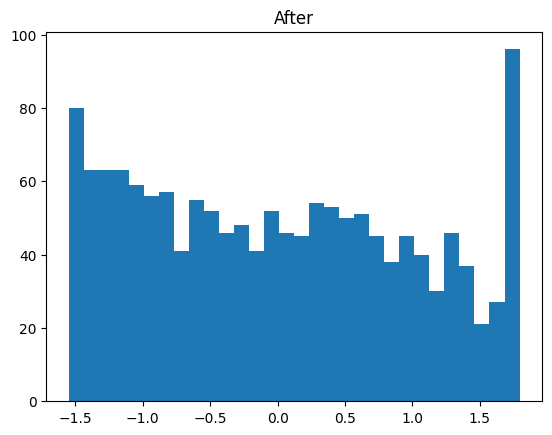


===== BÀI 3: MODEL + CV =====
Linear RMSE: 99703.97012141922
Linear STD: 5642.446612804177


KeyboardInterrupt: 

In [1]:
# -*- coding: utf-8 -*-
"""Untitled7.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1EAGC7MIutFGdkZURf_uVskqXJy3vuJk7
"""

# 🔥 LAB 8 - FULL
# =========================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


# =========================================================
# 🔥 LOAD DATA
# =========================================================
df = pd.read_csv("ITA105_Lab_8.csv")

target = 'SalePrice'  # ⚠️ sửa nếu khác

# Fix lỗi format
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

X = df.drop(columns=[target])
y = df[target]


# =========================================================
# 🔥 CHIA CỘT
# =========================================================
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()


# =========================================================
# 🔥 CUSTOM TRANSFORMER
# =========================================================
class OutlierRemover(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.array(X, dtype=float)
        self.Q1 = np.percentile(X, 25, axis=0)
        self.Q3 = np.percentile(X, 75, axis=0)
        self.IQR = self.Q3 - self.Q1
        return self

    def transform(self, X):
        X = np.array(X, dtype=float)
        lower = self.Q1 - 1.5 * self.IQR
        upper = self.Q3 + 1.5 * self.IQR
        return np.clip(X, lower, upper)


# =========================================================
# ======================= BÀI 1 ============================
# =========================================================
print("\n===== BÀI 1: PIPELINE =====")

# Pipeline từng loại
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierRemover()),
    ('scaler', StandardScaler()),
    ('power', PowerTransformer())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
], sparse_threshold=0) # Set sparse_threshold to 0 to always output a dense array

pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# Smoke test
X_sample = X.head(10)
X_trans = pipeline.fit_transform(X_sample)

print("Shape sau pipeline:", X_trans.shape)


# =========================================================
# ======================= BÀI 2 ============================
# =========================================================
print("\n===== BÀI 2: TEST PIPELINE =====")

def create_test_cases(X):
    cases = {}

    # 1. Full data
    cases['full'] = X.copy()

    # 2. Missing
    X_missing = X.copy()
    X_missing.iloc[:5] = np.nan
    cases['missing'] = X_missing

    # 3. Skew
    X_skew = X.copy()
    for col in numeric_cols:
        X_skew[col] = X_skew[col] ** 3
    cases['skew'] = X_skew

    # 4. Unseen
    X_unseen = X.copy()
    if categorical_cols:
        X_unseen[categorical_cols[0]] = "NEW_CATEGORY"
    cases['unseen'] = X_unseen

    # 5. Sai format
    X_wrong = X.copy()
    if numeric_cols:
        X_wrong[numeric_cols[0]] = "abc"
    cases['wrong_format'] = X_wrong

    return cases


cases = create_test_cases(X)

for name, data in cases.items():
    try:
        out = pipeline.fit_transform(data)
        print(f"{name}: OK - shape {out.shape}")
    except Exception as e:
        print(f"{name}: ERROR - {e}")


# So sánh phân phối
if len(numeric_cols) > 0:
    print("\nSo sánh phân phối...")

    col = numeric_cols[0]

    plt.hist(X[col], bins=30)
    plt.title("Before")
    plt.show()

    X_trans_full = pipeline.fit_transform(X)

    # X_trans_full is already a dense array due to sparse_threshold=0
    plt.hist(X_trans_full[:, 0], bins=30)
    plt.title("After")
    plt.show()


# =========================================================
# ======================= BÀI 3 ============================
# =========================================================
print("\n===== BÀI 3: MODEL + CV =====")

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    full_model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(full_model, X, y,
                             cv=kf,
                             scoring='neg_root_mean_squared_error')

    print(f"{name} RMSE:", -scores.mean())
    print(f"{name} STD:", scores.std())


# =========================================================
# ======================= BÀI 4 ============================
# =========================================================
print("\n===== BÀI 4: DEPLOY =====")

# Train model cuối
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

final_model.fit(X, y)

# Save model
joblib.dump(final_model, "house_price_model.pkl")
print("Đã lưu model!")


# Hàm dự đoán
def predict_price(file_path):
    model = joblib.load("house_price_model.pkl")

    new_data = pd.read_csv(file_path)

    # Fix format
    for col in new_data.columns:
        try:
            new_data[col] = pd.to_numeric(new_data[col])
        except:
            pass

    preds = model.predict(new_data)

    new_data['predicted_price'] = preds
    return new_data


# Test
print("\nTest dự đoán:")
print(predict_price("ITA105_Lab_8.csv").head())